 02 — THỜI GIAN (Time) · TP.HCM

> ### 📌 Đọc kèm `00_TONG_HOP_SO_SANH.ipynb`
>
> Notebook này đo giờ trên **giá cuối** và **hệ số nhân**. Điểm cần nhớ khi viết báo cáo:
> - η(giờ → **giá cơ bản**) ≈ 0,03 — rất nhỏ (giá cơ bản do quãng đường/thời gian quyết định)
> - η(giờ → **hệ số nhân**) ≈ 0,70 — **rất mạnh**, đây là kênh tác động thật
> - η(giờ → **giá cuối**) ≈ 0,30 — vì giá cuối = giá cơ bản × hệ số nhân
>
> → Kết luận đúng: **giờ ảnh hưởng mạnh đến giá khách trả, thông qua surge.**

> ### 📎 Đọc tiếp `07_bien_do_surge_gia.ipynb`
>
> Notebook này đo **tần suất** surge theo giờ (0,1% → 98,9%) — nhưng từ 5–23h hầu hết chuyến đều có
> surge (>90%) nên tần suất **bão hòa**, không còn phân biệt được các giờ trong khung này.
>
> `07_bien_do_surge_gia.ipynb` đo **biên độ (độ lớn)** thay vì tần suất, và trả lời câu hỏi
> *hệ số nhân giải thích bao nhiêu chênh lệch giá giữa các chuyến*.

In [1]:
import sys; sys.path.insert(0, ".")
from _common import *
setup()
df = load(frac=0.15)   # doi frac=1.0 de nap toan bo

Nap 1,034,550 dong (mau 15%) | gia median 114k VND | surge 81.7%


## 1. Giá & surge theo giờ trong ngày

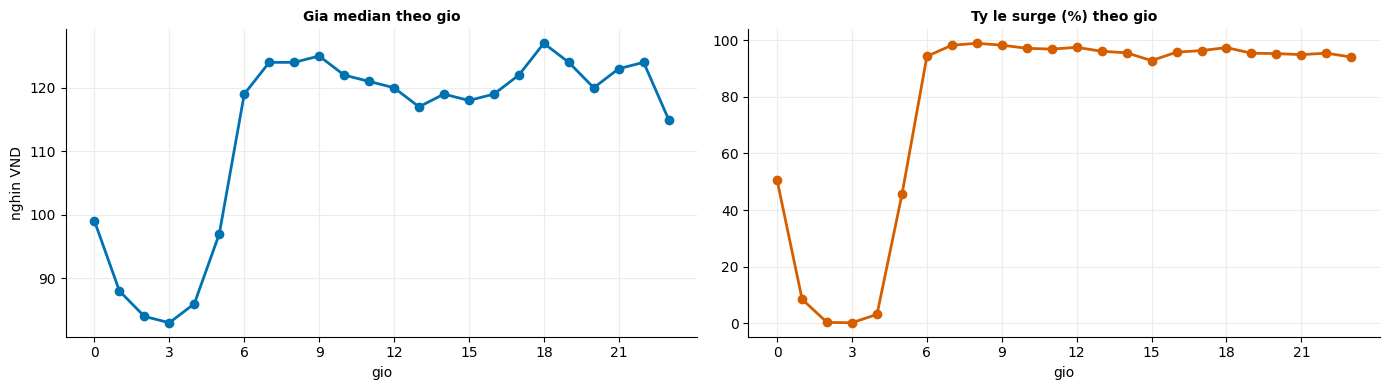

eta(gio, GIA)=0.296 | eta(gio, SURGE)=0.702
Surge: thap nhat 0.1% (gio 3) -> cao nhat 98.9% (gio 8)


In [2]:
h = df.groupby("gio_vn").agg(gia=("price_k","median"), surge_rate=("is_surge","mean"),
                                   surge_mean=(SURGE,"mean"), n=(PRICE,"size"))
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(h.index, h.gia, marker="o", color=BLUE, lw=2)
ax[0].set_title("Gia median theo gio", fontweight="bold", fontsize=10); ax[0].set_xlabel("gio"); ax[0].set_ylabel("nghin VND"); ax[0].set_xticks(range(0,24,3))
ax[1].plot(h.index, h.surge_rate*100, marker="o", color=RED, lw=2)
ax[1].set_title("Ty le surge (%) theo gio", fontweight="bold", fontsize=10); ax[1].set_xlabel("gio"); ax[1].set_xticks(range(0,24,3))
plt.tight_layout(); plt.show()
print(f"eta(gio, GIA)={eta(df.gio_vn, df[PRICE]):.3f} | eta(gio, SURGE)={eta(df.gio_vn, df[SURGE]):.3f}")
print(f"Surge: thap nhat {h.surge_rate.min()*100:.1f}% (gio {h.surge_rate.idxmin()}) -> cao nhat {h.surge_rate.max()*100:.1f}% (gio {h.surge_rate.idxmax()})")

## 2. Hai chiều của surge: tần suất vs cường độ theo giờ

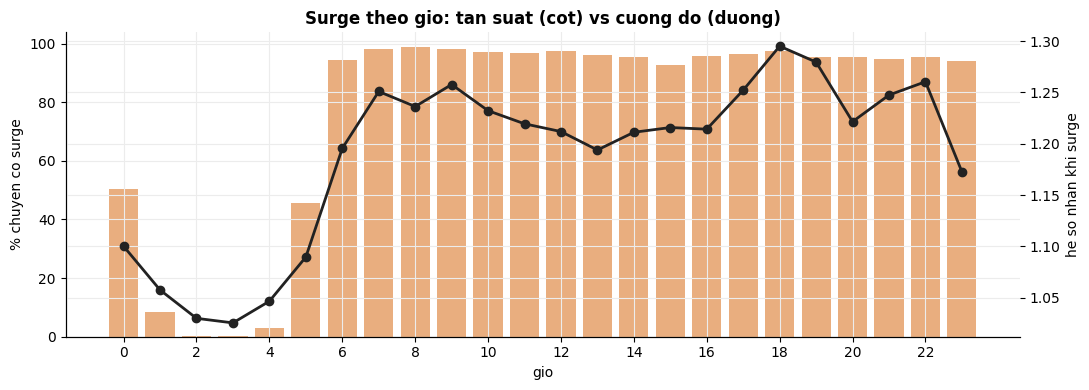

In [3]:
M = df[df.is_surge==1]
two = df.groupby("gio_vn").agg(tan_suat=("is_surge","mean"))
two["cuong_do"] = M.groupby("gio_vn")[SURGE].mean()
fig, ax = plt.subplots(figsize=(11,4))
ax.bar(two.index, two.tan_suat*100, color=RED, alpha=.5, label="Tan suat surge (%)")
ax2=ax.twinx(); ax2.plot(two.index, two.cuong_do, color="#222", marker="o", lw=2, label="Cuong do (he so nhan khi surge)")
ax.set_xlabel("gio"); ax.set_ylabel("% chuyen co surge"); ax2.set_ylabel("he so nhan khi surge")
ax.set_title("Surge theo gio: tan suat (cot) vs cuong do (duong)", fontweight="bold"); ax.set_xticks(range(0,24,2))
plt.tight_layout(); plt.show()

## 3. Theo thứ & cuối tuần

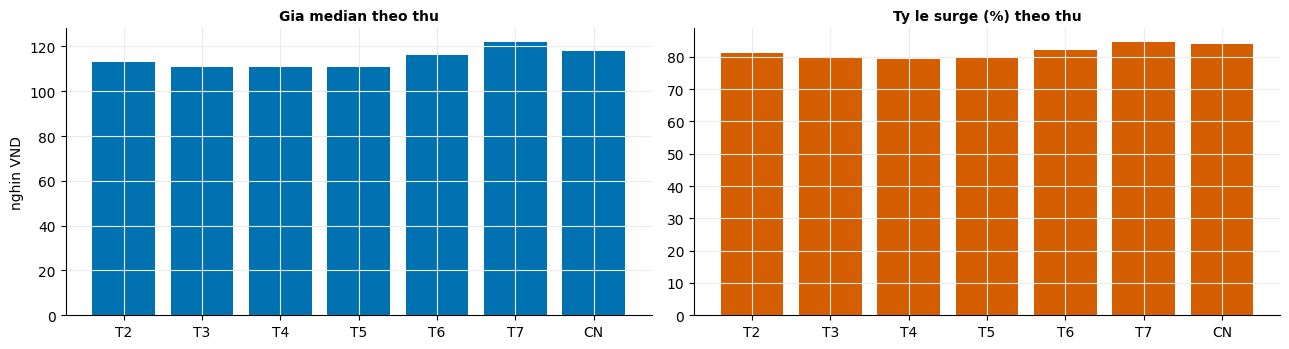

Cuoi tuan vs ngay thuong (surge rate): {0: 0.807, 1: 0.84}


In [4]:
wd = df.groupby("thu_vn").agg(gia=("price_k","median"), surge_rate=("is_surge","mean"))
ten_thu = ["T2","T3","T4","T5","T6","T7","CN"]
fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
ax[0].bar(range(7), wd.gia.reindex(range(7)), color=BLUE); ax[0].set_xticks(range(7)); ax[0].set_xticklabels(ten_thu)
ax[0].set_title("Gia median theo thu", fontweight="bold", fontsize=10); ax[0].set_ylabel("nghin VND")
ax[1].bar(range(7), wd.surge_rate.reindex(range(7))*100, color=RED); ax[1].set_xticks(range(7)); ax[1].set_xticklabels(ten_thu)
ax[1].set_title("Ty le surge (%) theo thu", fontweight="bold", fontsize=10)
plt.tight_layout(); plt.show()
print("Cuoi tuan vs ngay thuong (surge rate):", df.groupby("target_is_weekend").is_surge.mean().round(3).to_dict())

## 4. Heatmap Giờ × Thứ (tỷ lệ surge)

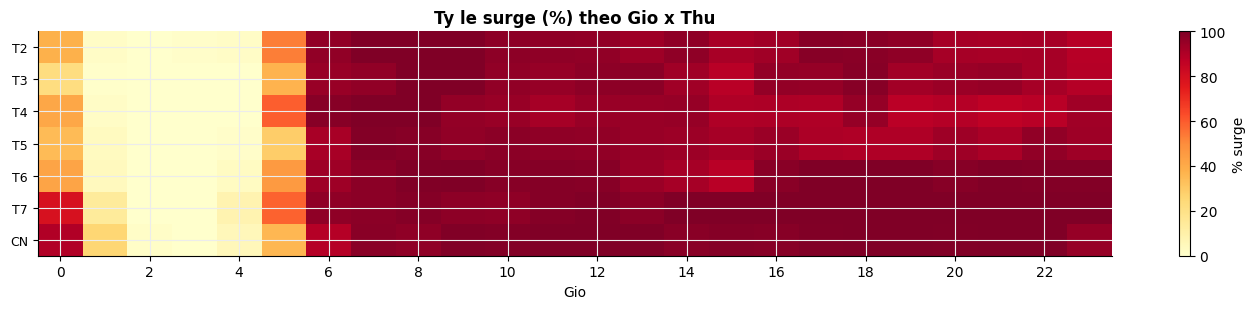

In [5]:
hm = df.pivot_table(index="thu_vn", columns="gio_vn", values="is_surge", aggfunc="mean")*100
fig, ax = plt.subplots(figsize=(14, 3.2))
im = ax.imshow(hm.values, aspect="auto", cmap="YlOrRd")
ax.set_yticks(range(7)); ax.set_yticklabels(ten_thu, fontsize=9)
ax.set_xticks(range(0,24,2)); ax.set_xticklabels(range(0,24,2))
ax.set_xlabel("Gio"); ax.set_title("Ty le surge (%) theo Gio x Thu", fontweight="bold")
plt.colorbar(im, ax=ax, label="% surge"); plt.tight_layout(); plt.show()

---
## Biến thiên chi tiết theo giờ — tách từng khu (cùng quãng đường)

Cố định dải quãng đường **4–6 km** để so công bằng, xem theo giờ: **tắc đường (ETA) · cung–cầu ·
giá & surge** — mỗi cái tách riêng 3 khu.

In [6]:
# --- Chi tiet theo gio: co dinh dai quang duong 4-6km de so cong bang, tach 3 khu ---
LO, HI = 4, 6
band = df[(df.quote_distance >= LO) & (df.quote_distance <= HI)].copy()
KHU = list(df.pickup_location_name.unique())
MAU = {KHU[0]: BLUE, KHU[1]: ORANGE, KHU[2]: GREEN}
print(f"Dai {LO}-{HI}km: {len(band):,} chuyen (tach 3 khu: {KHU})")

Dai 4-6km: 395,062 chuyen (tach 3 khu: ['Crescent Mall', 'SC Vivo City', 'EcoGreen Sài Gòn'])


### 1) 🚦 Thời lượng ETA & tốc độ theo giờ (cùng quãng đường 4–6 km)

Cùng quãng đường, nếu giờ nào ETA dài hơn / tốc độ thấp hơn → giờ đó tắc hơn.

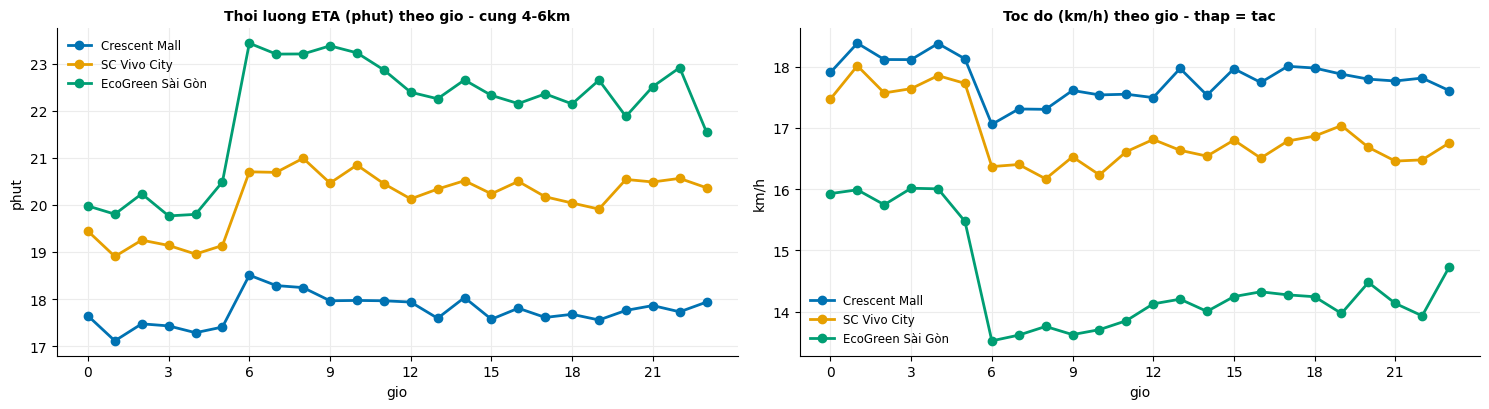

Bien do ETA theo gio (cung 4-6km):
  Crescent Mall        17-19 phut (chenh 1p) | tac nhat gio 6
  SC Vivo City         19-21 phut (chenh 2p) | tac nhat gio 8
  EcoGreen Sài Gòn     20-23 phut (chenh 4p) | tac nhat gio 6


In [7]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4.2))
for khu in KHU:
    b = band[band.pickup_location_name==khu]
    eta_h = b.groupby("gio_vn").quote_duration.median()/60
    spd_h = b.groupby("gio_vn").speed_kmh.median()
    ax[0].plot(eta_h.index, eta_h.values, marker="o", lw=2, color=MAU[khu], label=khu)
    ax[1].plot(spd_h.index, spd_h.values, marker="o", lw=2, color=MAU[khu], label=khu)
ax[0].set_title("Thoi luong ETA (phut) theo gio - cung 4-6km", fontweight="bold", fontsize=10)
ax[0].set_xlabel("gio"); ax[0].set_ylabel("phut"); ax[0].set_xticks(range(0,24,3)); ax[0].legend(frameon=False, fontsize=8.5)
ax[1].set_title("Toc do (km/h) theo gio - thap = tac", fontweight="bold", fontsize=10)
ax[1].set_xlabel("gio"); ax[1].set_ylabel("km/h"); ax[1].set_xticks(range(0,24,3)); ax[1].legend(frameon=False, fontsize=8.5)
plt.tight_layout(); plt.show()

# bien do theo gio tung khu
print("Bien do ETA theo gio (cung 4-6km):")
for khu in KHU:
    e = band[band.pickup_location_name==khu].groupby("gio_vn").quote_duration.median()/60
    print(f"  {khu:20} {e.min():.0f}-{e.max():.0f} phut (chenh {e.max()-e.min():.0f}p) | tac nhat gio {e.idxmax()}")

> **Đọc:** nếu đường **khá phẳng** → tắc đường trong bộ này **ít biến thiên theo giờ** (khác
> kỳ vọng "giờ cao điểm tắc hơn"). Khu nào nằm **cao hơn** = nền tắc hơn (EcoGreen thường chậm hơn).

### 2) ⚡ Cung–cầu theo giờ (tách khu)

`demand_index` (cầu), `supply_index` (cung), `market_imbalance` (cầu/cung — cao = thiếu xe).

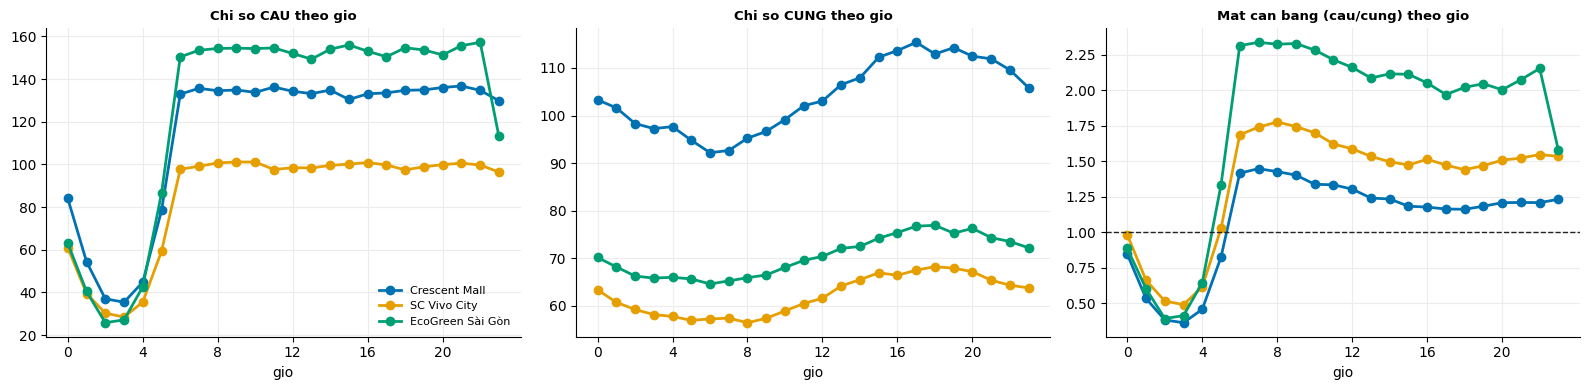

Bien do theo gio (toan bo):
  Chi so CAU                 30.2 -> 131.0 (cao nhat gio 11)
  Chi so CUNG                67.7 -> 80.4 (cao nhat gio 18)
  Mat can bang (cau/cung)    0.4 -> 1.8 (cao nhat gio 8)


In [8]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
metrics = [("pricing_demand_index_5m_lag","Chi so CAU"),
           ("pricing_supply_index_5m_lag","Chi so CUNG"),
           ("pricing_market_imbalance_5m_lag","Mat can bang (cau/cung)")]
for a,(col,ten) in zip(ax, metrics):
    for khu in KHU:
        v = df[df.pickup_location_name==khu].groupby("gio_vn")[col].median()
        a.plot(v.index, v.values, marker="o", lw=2, color=MAU[khu], label=khu)
    a.set_title(ten+" theo gio", fontweight="bold", fontsize=9.5); a.set_xlabel("gio"); a.set_xticks(range(0,24,4))
ax[2].axhline(1.0, color="#222", ls="--", lw=1, label="can bang (=1)")
ax[0].legend(frameon=False, fontsize=8); plt.tight_layout(); plt.show()

print("Bien do theo gio (toan bo):")
for col,ten in metrics:
    v = df.groupby("gio_vn")[col].median()
    print(f"  {ten:26} {v.min():.1f} -> {v.max():.1f} (cao nhat gio {v.idxmax()})")

> **Đọc:** **cầu** dao động rất mạnh theo giờ (giờ cao điểm cầu vọt lên), cung ổn định hơn →
> `market_imbalance` (cầu/cung) tăng vọt lúc cao điểm → đẩy surge. Đây là động lực chính của surge.

### 3) 💰 Giá & surge theo giờ (cùng quãng đường 4–6 km, tách khu)

Cùng quãng đường → thay đổi giá/surge theo giờ chủ yếu do **surge** (không phải do quãng đường).

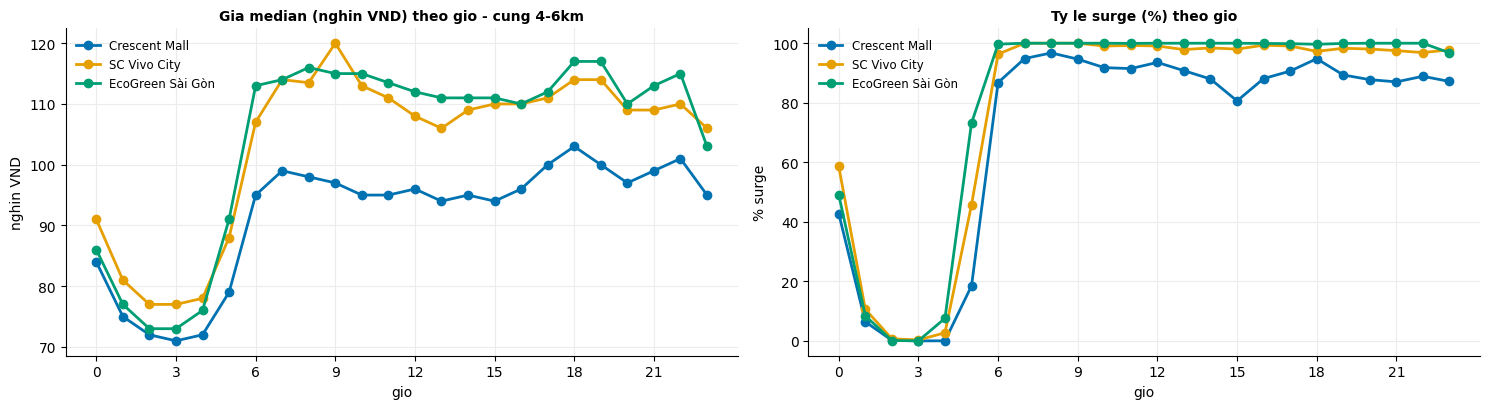

Cung dai 4-6km:
  Crescent Mall        gia 71k-103k | surge 0%-97%
  SC Vivo City         gia 77k-120k | surge 0%-100%
  EcoGreen Sài Gòn     gia 73k-117k | surge 0%-100%


In [9]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4.2))
for khu in KHU:
    b = band[band.pickup_location_name==khu]
    gia_h = b.groupby("gio_vn").price_k.median()
    sur_h = b.groupby("gio_vn").is_surge.mean()*100
    ax[0].plot(gia_h.index, gia_h.values, marker="o", lw=2, color=MAU[khu], label=khu)
    ax[1].plot(sur_h.index, sur_h.values, marker="o", lw=2, color=MAU[khu], label=khu)
ax[0].set_title("Gia median (nghin VND) theo gio - cung 4-6km", fontweight="bold", fontsize=10)
ax[0].set_xlabel("gio"); ax[0].set_ylabel("nghin VND"); ax[0].set_xticks(range(0,24,3)); ax[0].legend(frameon=False, fontsize=8.5)
ax[1].set_title("Ty le surge (%) theo gio", fontweight="bold", fontsize=10)
ax[1].set_xlabel("gio"); ax[1].set_ylabel("% surge"); ax[1].set_xticks(range(0,24,3)); ax[1].legend(frameon=False, fontsize=8.5)
plt.tight_layout(); plt.show()

print("Cung dai 4-6km:")
for khu in KHU:
    b = band[band.pickup_location_name==khu]
    g = b.groupby("gio_vn").price_k.median(); s = b.groupby("gio_vn").is_surge.mean()
    print(f"  {khu:20} gia {g.min():.0f}k-{g.max():.0f}k | surge {s.min()*100:.0f}%-{s.max()*100:.0f}%")

### 4) Đối chiếu 3 tín hiệu cùng 1 khung (1 khu mẫu)

Xem trên cùng trục giờ: cầu ↑ → imbalance ↑ → surge ↑ → giá ↑. Còn ETA (tắc) thì phẳng.

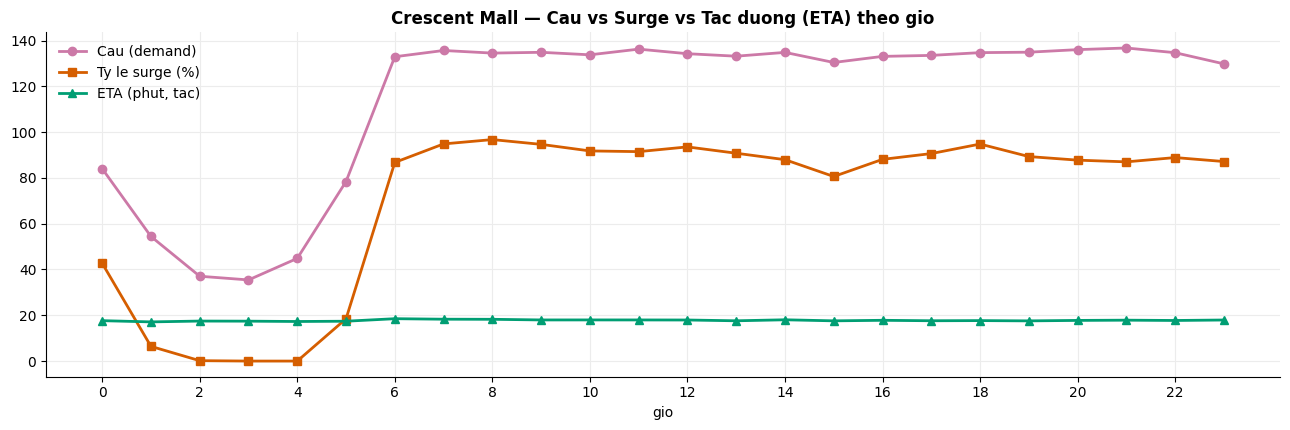

In [10]:
khu0 = KHU[0]
b = band[band.pickup_location_name==khu0]
dd0 = df[df.pickup_location_name==khu0]
fig, ax = plt.subplots(figsize=(13, 4.4))
hh = range(24)
ax.plot(hh, dd0.groupby("gio_vn").pricing_demand_index_5m_lag.median().reindex(hh), color=PURPLE, lw=2, marker="o", label="Cau (demand)")
ax.plot(hh, b.groupby("gio_vn").is_surge.mean().reindex(hh)*100, color=RED, lw=2, marker="s", label="Ty le surge (%)")
ax.plot(hh, b.groupby("gio_vn").quote_duration.median().reindex(hh)/60, color=GREEN, lw=2, marker="^", label="ETA (phut, tac)")
ax.set_title(f"{khu0} — Cau vs Surge vs Tac duong (ETA) theo gio", fontweight="bold")
ax.set_xlabel("gio"); ax.set_xticks(range(0,24,2)); ax.legend(frameon=False)
plt.tight_layout(); plt.show()

,T2,T3,T4,T5,T6,T7,CN
pickup_location_name,,,,,,,
Crescent Mall,50437,46975,46610,49823,51150,52113,52094
EcoGreen Sài Gòn,48507,43871,44676,47443,49018,49583,50112
SC Vivo City,51483,47595,47413,49745,51646,51979,52277


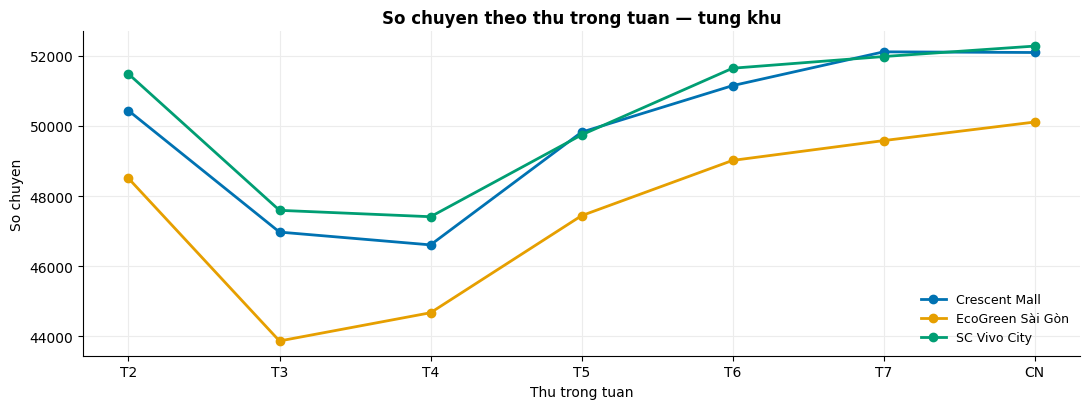

In [11]:
ten_thu = ["T2","T3","T4","T5","T6","T7","CN"]

# Bang: so chuyen theo THU x KHU
sc = (df.groupby(["pickup_location_name","thu_vn"]).size()
        .unstack("thu_vn").reindex(columns=range(7)))
sc.columns = ten_thu
display(sc)

# Bieu do DUONG: moi khu 1 duong
fig, ax = plt.subplots(figsize=(11, 4.2))
mau = [BLUE, ORANGE, GREEN]
for i, khu in enumerate(sc.index):
    ax.plot(range(7), sc.loc[khu].values, marker="o", lw=2, color=mau[i % 3], label=khu)
ax.set_xticks(range(7)); ax.set_xticklabels(ten_thu)
ax.set_ylabel("So chuyen"); ax.set_xlabel("Thu trong tuan")
ax.set_title("So chuyen theo thu trong tuan — tung khu", fontweight="bold")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()


In [12]:
P, M = "target_shown_price", "target_shown_multiplier"
df["base"] = df[P] / df[M]     # gia co so suy nguoc = gia / he so nhan

print("1) GIA CO SO do gi quyet dinh (dung chuyen KHONG surge de base = gia that):")
ns = df[df[M] == 1.0]
print(f"   corr(base, quang duong)                      = {ns.base.corr(ns.quote_distance):.3f}")
print(f"   corr(base, thoi luong/tac duong)             = {ns.base.corr(ns.quote_duration):.3f}")
dbin = binned(ns.quote_distance, 10)
r = ns.groupby(dbin).apply(lambda x: x.base.corr(x.quote_duration)).mean()
print(f"   corr(base, tac duong) | CUNG quang duong     = {r:.3f}  <- tac duong nam trong GIA CO SO")

print("\n2) CUNG dich vu + CUNG quang duong -> gi giai thich chenh gia?")
sub = df[(df.service_name==df.service_name.iloc[0]) & (df.quote_distance.between(5,5.5))]
print(f"   corr(gia cuoi, he so nhan)   = {sub[P].corr(sub[M]):.3f}   (surge)")
print(f"   corr(gia cuoi, thoi luong)   = {sub[P].corr(sub.quote_duration):.3f}   (tac duong)")

print("\n3) HE SO NHAN bam theo gi?")
print(f"   corr(mult, cung-cau imbalance) = {df[M].corr(df.pricing_market_imbalance_5m_lag):.3f}")
print(f"   corr(mult, tac duong)          = {df[M].corr(df.quote_duration):.3f}   (yeu -> tac duong KHONG o day)")


1) GIA CO SO do gi quyet dinh (dung chuyen KHONG surge de base = gia that):
   corr(base, quang duong)                      = 0.774
   corr(base, thoi luong/tac duong)             = 0.688
   corr(base, tac duong) | CUNG quang duong     = 0.427  <- tac duong nam trong GIA CO SO

2) CUNG dich vu + CUNG quang duong -> gi giai thich chenh gia?
   corr(gia cuoi, he so nhan)   = 0.621   (surge)
   corr(gia cuoi, thoi luong)   = 0.476   (tac duong)

3) HE SO NHAN bam theo gi?
   corr(mult, cung-cau imbalance) = 0.798
   corr(mult, tac duong)          = 0.203   (yeu -> tac duong KHONG o day)


---
## Kết luận — Thời gian (tổng hợp)

- **→ Giá:** giờ ảnh hưởng vừa; trên cùng quãng đường, giá đổi theo giờ **chủ yếu do surge**.
- **→ Hệ số nhân:** giờ ảnh hưởng **CỰC MẠNH** (η ~0,70) — surge 0% → ~100% theo giờ. Động lực là
  **cầu/cung** (cầu vọt lúc cao điểm), không phải tắc đường.
- **🚦 Tắc đường (ETA) gần như phẳng theo giờ** trong bộ này — tạo khác biệt *giữa các chuyến*
  (6km/8p vs 6km/40p) chứ ít tạo khác biệt *theo giờ*. Mỗi khu có nền tắc riêng (EcoGreen chậm nhất).
- Giờ tác động chủ yếu lên **tần suất** surge; cường độ ổn định hơn.